In [68]:
from solver_selection_thm.physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt

In [69]:
from spe_runscript import make_solver_space_scheme_hm

solver_space = SolverSpace(
    solver_space_scheme=make_solver_space_scheme_hm(nd=3),
    solver_scheme_builders=KNOWN_SOLVER_COMPONENTS_THM,
)
num_solvers = len(solver_space.all_decisions_encoding)
print(solver_space.decision_tree)
print("Num solvers:", num_solvers)

performance_predictor = PerformancePredictorPassiveAgressive(
    num_solvers=num_solvers,
)
solver_selector = SolverSelector(
    # reward_estimator=RewardEstimator(),
    solver_space=solver_space,
    performance_predictor=performance_predictor,
)

block_type: PetscKSPScheme
| ksp_gmres_restart: Choices from 10 to 50, len = 3
| block_type (fork with 1 branches):
| | block_type: PetscFieldSplitScheme
| | | elim_options (fork with 2 branches):
| | | | python_pc_type: pbjacobi
| | | | python_pc_type: hypre
| | | | | python_pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.9, len = 3
| | | | | python_pc_hypre_boomeramg_agg_nl: Choices from 0 to 2, len = 3
| | | | | python_pc_hypre_boomeramg_relax_type_all (fork with 1 branches):
| | | | | | symmetric-SOR/Jacobi
Num solvers: 30


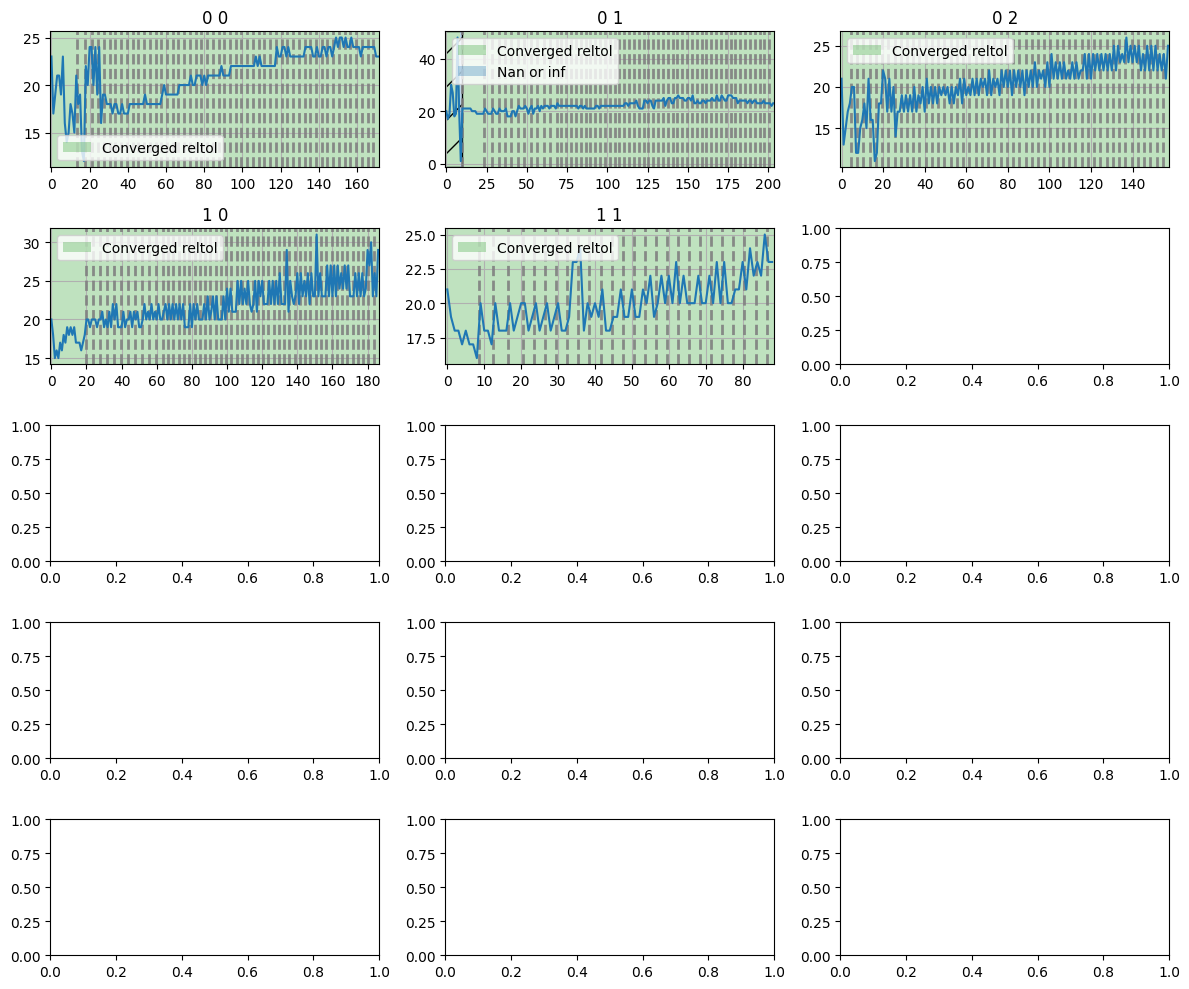

In [70]:
from itertools import count
from copy import copy
from plot_utils import (
    color_converged_reason,
    color_time_steps,
    get_gmres_iterations,
    load_data,
    get_cfl,
    get_enthalpy_max,
    get_peclet_max,
    get_temp_max,
    get_temp_min,
    get_num_sticking_sliding_open,
    get_linear_solve_time
)
from solver_selection_thm.spe_physics import X_SLICES, Z_SLICES, simulation_name, params


data_simulations = []
solver_selection_history = []

np.random.seed(42)
run_idx = 1
Z_SLICES = copy(Z_SLICES)
X_SLICES = copy(X_SLICES)
np.random.shuffle((Z_SLICES))
np.random.shuffle((X_SLICES))


for z_slice in Z_SLICES:
    data_row = []
    data_simulations.append(data_row)
    for x_slice in X_SLICES:
        params["x_slice"] = x_slice
        params["z_slice"] = z_slice
        sim_name = f"run_{run_idx}_{simulation_name(params)}"
        try:
            data = load_data(f"../stats/{sim_name}.json")
            solver_selector.history.load(f"../stats/solver_selection_history_{sim_name}.npy")
            solver_selection_history.append(copy(solver_selector.history))
            data_row.append(data)
        except FileNotFoundError:
            solver_selection_history.append(None)
            data_row.append(None)


fig, axes = plt.subplots(
    nrows=len(Z_SLICES), ncols=len(X_SLICES), figsize=(12, 10)
)
for i, data_row in enumerate(data_simulations):
    for j, data in enumerate(data_row):
        if data == None:
            continue
        ax = axes[i][j]
        plt.sca(ax)

        color_converged_reason(data, legend=True)
        color_time_steps(data)
        plt.legend()

        ax.plot(get_gmres_iterations(data))
        # ax.set_yscale('log')
        # print(inlet_placement, outlet_placement)
        ax.set_title(f"{i} {j}")

plt.tight_layout()

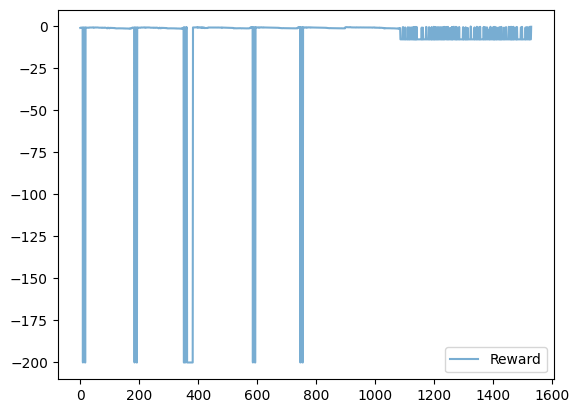

In [71]:
from solver_selection_thm.selector import SolverSelectorHistory
common_history = SolverSelectorHistory()
for x in solver_selection_history:
    if x is None:
        continue
    common_history.features.extend(x.features)
    common_history.reward.extend(x.reward)
    common_history.decision_idx.extend(x.decision_idx)
    common_history.greedy.extend(x.greedy)   
    common_history.expectation.extend(x.expectation)

# plt.plot(common_history.expectation, label='Expectation', alpha=0.6)
plt.plot(common_history.reward, label='Reward', alpha=0.6)
plt.legend()
# plt.ylim(-2, 0)

In [72]:
print(len(common_history.reward))
print(len(common_history.features))

1529
1529


In [73]:
decision_id = np.array(common_history.decision_idx)
X, y = np.array(common_history.features), np.array(common_history.reward)

FAIL_REWARD = -100
plt.plot(y[y > FAIL_REWARD])

success = y > FAIL_REWARD
# y = y[success]
# X = X[success]
# X.shape

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (1529,) + inhomogeneous part.

## Can we classify to failed/not failed?

(array([ 32., 705.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

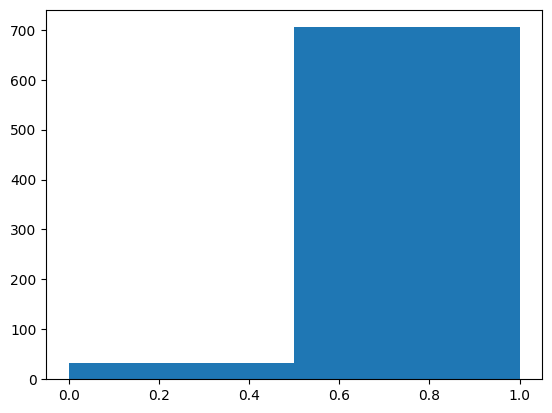

In [ ]:
ycat = success
plt.hist(ycat.astype(int), bins=2)

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from solver_selection_thm.performance_predictor import SuccessClassifier


classifier = SuccessClassifier()

cv_results = cross_validate(
    classifier,
    X,
    ycat,
    cv=5,
    scoring="average_precision",
    return_train_score=True,
    return_estimator=True,
)
print("Train scores:", cv_results["train_score"])
print("Test scores:", cv_results["test_score"])
print("Mean Train:", np.mean(cv_results["train_score"]))
print("Mean Test:", np.mean(cv_results["test_score"]))

Train scores: [1. 1. 1. 1. 1.]
Test scores: [1.         1.         0.99940896 1.         1.        ]
Mean Train: 1.0
Mean Test: 0.9998817928898633


In [ ]:
import math


class OnlineClassifier(ClassifierMixin, BaseEstimator):

    def __init__(self, Xoffline, yoffline):
        self.classes_ = np.array([False, True])
        self.Xoffline = Xoffline
        self.yoffline = yoffline
        self.classifier = SuccessClassifier()
        self.classifier.fit(Xoffline, yoffline)
        self.window_size = 1

    def fit(self, X, y):
        for i in range(math.ceil(X.shape[0] / self.window_size)):
            start = i * self.window_size
            end = start + self.window_size
            Xbatch, ybatch = X[start:end], y[start:end]
            self.classifier.partial_fit(Xbatch, ybatch)
        return self

    def predict(self, X):
        return self.classifier.predict(X)

    def predict_proba(self, X):
        return self.classifier.predict_proba((X))

    def decision_function(self, X):
        return self.classifier.decision_function((X))


sep = num_solvers
Xoffline, ycat_offline = X[:sep], ycat[:sep]
Xonline, ycat_online = X[sep:], ycat[sep:]

online_classifier = OnlineClassifier(Xoffline, ycat_offline)

cv_results = cross_validate(
    online_classifier,
    Xonline,
    ycat_online,
    cv=5,
    scoring="average_precision",
    return_train_score=True,
    return_estimator=True,
    n_jobs=1
)
print("Train scores:", cv_results["train_score"])
print("Test scores:", cv_results["test_score"])
print("Mean Train:", np.mean(cv_results["train_score"]))
print("Mean Test:", np.mean(cv_results["test_score"]))

Train scores: [1.         1.         1.         0.99971877 1.        ]
Test scores: [1. 1. 1. 1. 1.]
Mean Train: 0.9999437536730376
Mean Test: 1.0


Split to xsuccess and xfail

In [ ]:
Xsuccess = X[success]
ysuccess = y[success]

# In offline setting, how well does the data describe the target?
1. Estimating Mutual Information (MI)


<BarContainer object of 17 artists>

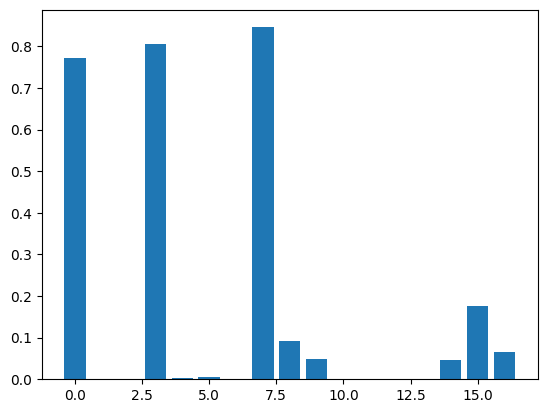

In [ ]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# compute MI
mi = mutual_info_regression(
    StandardScaler().fit_transform(Xsuccess), ysuccess, n_neighbors=10, random_state=42
)
plt.bar(range(len(mi)), mi)

2. Training offline model with cross-validation and comparing its

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.linear_model import PassiveAggressiveRegressor, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from solver_selection_thm.performance_predictor import RewardRegressor
from sklearn.base import RegressorMixin



offline_pipeline = RewardRegressor()
# offline_pipeline = KNeighborsRegressor()

cv_results = cross_validate(offline_pipeline, Xsuccess, ysuccess, cv=5, scoring="r2", return_train_score=True, return_estimator=True)

# Output
print("Train R² scores:", cv_results["train_score"])
print("Test R² scores:", cv_results["test_score"])
print("Mean Train R²:", np.mean(cv_results["train_score"]))
print("Mean Test R²:", np.mean(cv_results["test_score"]))

best_regressor_offline = cv_results['estimator'][np.argmax(cv_results['test_score'])]
best_regressor_offline

Train R² scores: [0.64390839 0.58628665 0.63015118 0.87300322 0.62788497]
Test R² scores: [-5.75193282e-01  5.90252033e-01  3.66422661e-01 -8.43959316e+03
  1.48436858e-01]
Mean Train R²: 0.6722468810907043
Mean Test R²: -1687.8126493116747


RewardRegressor()

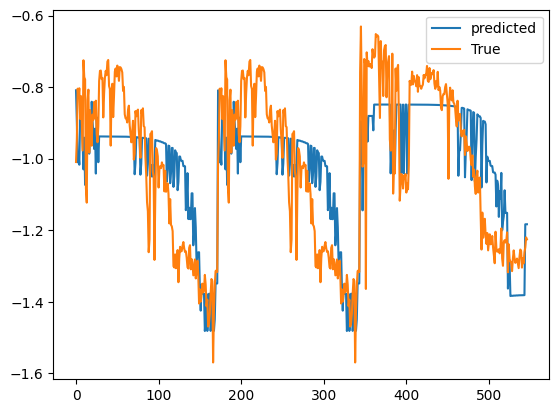

In [ ]:
plt.plot(best_regressor_offline.predict(Xsuccess), label='predicted')
plt.plot(ysuccess, label='True')
plt.legend()

3. We split success data into offline and online. Online data is to be used for cross-validation split to train and test.

In [ ]:
sep = np.sum(success[:num_solvers])
Xoffline, yoffline = Xsuccess[:sep], ysuccess[:sep]
Xonline, yonline = Xsuccess[sep:], ysuccess[sep:]

3. Cross-validation R2 score of the online model

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
import math


class OnlineRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, Xoffline, yoffline):
        self.Xoffline = Xoffline
        self.yoffline = yoffline
        self.regressor = RewardRegressor()
        self.regressor.fit(Xoffline, yoffline)
        self.window_size = 1

    def fit(self, X, y):
        for i in range(math.ceil(X.shape[0] / self.window_size)):
            start = i * self.window_size
            end = start + self.window_size
            Xbatch, ybatch = X[start:end], y[start:end]
            self.regressor.partial_fit(Xbatch, ybatch)

    def predict(self, X):
        return self.regressor.predict(X)

    

online_regressor = OnlineRegressor(Xoffline, yoffline)
cv_results_online = cross_validate(online_regressor, Xonline, yonline, cv=6, scoring="r2", return_train_score=True, return_estimator=True)

# Output
print("Train R² scores:", cv_results_online["train_score"])
print("Test R² scores:", cv_results_online["test_score"])
print("Mean Train R²:", np.mean(cv_results_online["train_score"]))
print("Mean Test R²:", np.mean(cv_results_online["test_score"]))

best_regressor_online = cv_results_online['estimator'][np.argmax(cv_results_online['test_score'])]
best_regressor_online

Train R² scores: [ 0.04864911 -0.14200853 -0.17774674  0.06171762 -0.20358423  0.14805567]
Test R² scores: [-7.51792446e-01 -1.13253341e+00 -2.07003850e+00 -3.22761889e+03
 -1.64485861e-01 -1.36531107e+00]
Mean Train R²: -0.04415284881640472
Mean Test R²: -538.8505081417785


,Xoffline,array([[8.640...0000000e+00]])
,yoffline,array([-1.009... -0.9540548 ])


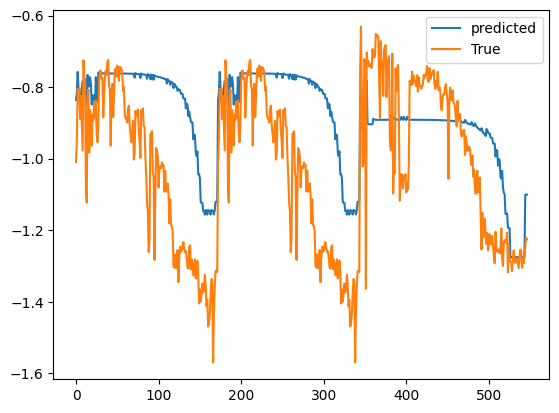

In [ ]:
plt.plot(best_regressor_online.predict(Xsuccess), label='predicted')
plt.plot(ysuccess, label='True')
plt.legend()

4. Now we treat them as classifiers. Offline - ground truth. How often does Online make different decisions? How much does this cost to it?

In [ ]:
class TwoEstimators:

    def __init__(self, classifier, regressor):
        self.classifier = classifier
        self.regressor = regressor

    def fit(self, X, y):
        success = y >= FAIL_REWARD
        self.classifier.fit(X, success)
        self.regressor.fit(X[success], y[success])

    def partial_fit(self, X, y):
        X = np.array(X).reshape(1, -1)
        y = np.atleast_1d(y)
        success = y >= FAIL_REWARD
        self.classifier.partial_fit(X, success)
        if success:
            self.regressor.partial_fit(X[success], y[success])

    def predict(self, X):
        reward_estimate = np.full(X.shape[0], FAIL_REWARD, dtype=float)
        success_estimate = self.classifier.predict(X)
        if not np.any(success_estimate):
            return reward_estimate

        reward_estimate[success_estimate] = self.regressor.predict(X[success_estimate])
        return reward_estimate

In [ ]:
sep = num_solvers
Xoffline, yoffline = X[:sep], y[:sep]
Xonline, yonline = X[sep:], y[sep:]
print(Xoffline.shape, yoffline.shape, Xonline.shape, yonline.shape)

(30, 17) (30,) (546, 17) (546,)


In [30]:
from sklearn.neighbors import KNeighborsRegressor

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)


best_regressor_offline = TwoEstimators(classifier=SuccessClassifier(), regressor=KNeighborsRegressor())
best_regressor_offline.fit(X, y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding
Xonline_features.shape

regressor_online = TwoEstimators(classifier=SuccessClassifier(), regressor=RewardRegressor())
regressor_online.fit(Xoffline, yoffline)

decisions_online = []
decisions_offline = []
reward_offline = []
reward_online = []
reward_feedback = []

for Xfeature in Xonline_features:
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    predictions_online = regressor_online.predict(x_to_predict)
    max_score_idx_online = np.argmax(predictions_online)
    max_score_online = predictions_online[max_score_idx_online]

    # offline
    predictions_offline = best_regressor_offline.predict(x_to_predict)
    max_score_idx_offline = np.argmax(predictions_offline)
    max_score_offline = predictions_offline[max_score_idx_offline]

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    regressor_online.partial_fit(X_feedback, [y_feedback])

    # saving stats
    decisions_offline.append(max_score_idx_offline)
    decisions_online.append(max_score_idx_online)
    reward_feedback.append(y_feedback)
    reward_offline.append(max_score_offline)
    reward_online.append(max_score_online)

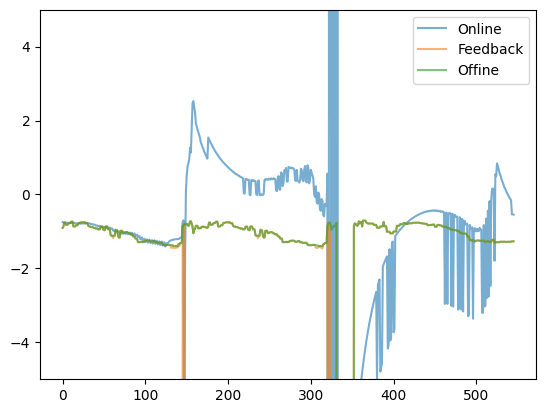

In [76]:
plt.plot(reward_online, label='Online', alpha=0.6)
plt.plot(reward_feedback, label='Feedback', alpha=0.6)
plt.plot(reward_offline, label='Offine', alpha=0.6)
plt.ylim(-5, 5)
plt.legend()

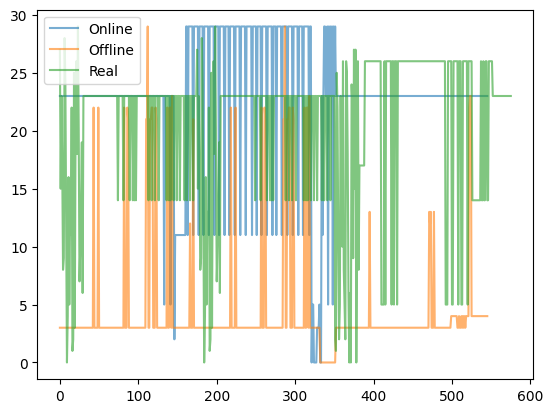

In [24]:
plt.plot(decisions_online, label='Online', alpha=0.6)
plt.plot(decisions_offline, label='Offline', alpha=0.6)
plt.plot(common_history.decision_idx, label='Real', alpha=0.6)
plt.legend()

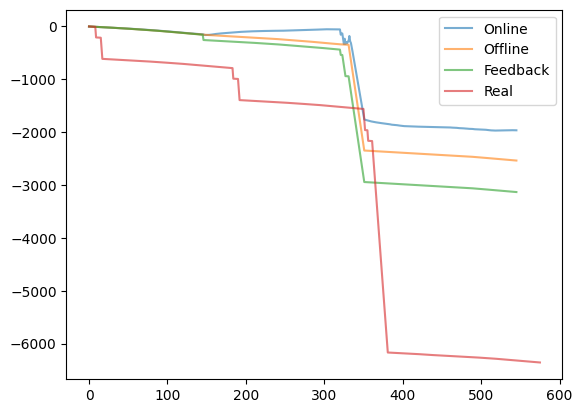

In [28]:
plt.plot(np.cumsum(reward_online), label='Online', alpha=0.6)
plt.plot(np.cumsum(reward_offline), label='Offline', alpha=0.6)
plt.plot(np.cumsum(reward_feedback), label='Feedback', alpha=0.6)
plt.plot(np.cumsum(common_history.reward), label='Real', alpha=0.6)
plt.legend()

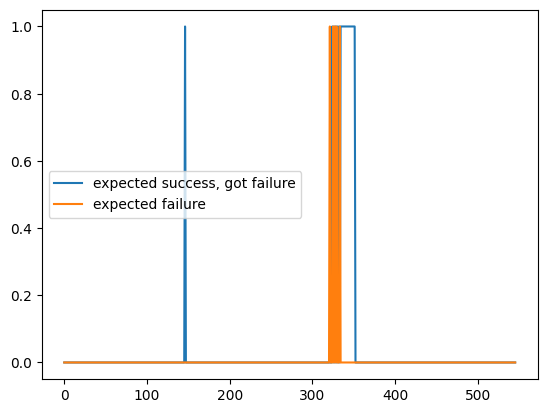

In [77]:
expected_success = np.array(reward_online) > FAIL_REWARD
decesion_lead_to_fail = np.array(reward_feedback) <= FAIL_REWARD
plt.plot(expected_success * decesion_lead_to_fail, label='expected success, got failure')
plt.plot(np.logical_not(expected_success), label='expected failure')
plt.legend()